# Available Transfer Capability and the Simultaneous-Feasibility Test on the WSCC 9-Bus

Before a balancing authority joins a nodal market, it sells transmission the OATT
way: **point-to-point service** from a point of receipt (POR) to a point of
delivery (POD), rated by **Available Transfer Capability (ATC)**. This notebook
builds three things on the 9-bus network:

1. how ATC follows from a path's transfer limit (TTC) and the NERC identity
   $\mathrm{ATC} = \mathrm{TTC} - \mathrm{TRM} - \mathrm{ETC} - \mathrm{CBM}$;
2. the **simultaneous-feasibility test (SFT)** that a *set* of awards must pass --
   the condition behind revenue adequacy for transmission rights; and
3. the central Western failure mode -- when two balancing authorities each compute
   ATC on their own slice of the network and sell all of it, the combined awards
   **oversubscribe** the simultaneously feasible set through loop flow.

It is one idea throughout: the path shift factor $a_\ell = SF_{\ell,s} - SF_{\ell,k}$,
applied first to a single transaction, then to a set.

## 0. Setup

In [1]:
#@title ▶ Run me first ▶ Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# helper modules next to the notebook. Running locally it does nothing (the
# modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
              "wscc9_model.py", "footprints.py", "revenue_allocation.py",
              "wscc9_figures.py", "atc.py", "bilateral.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")

Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, atc, bilateral
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, atc, bilateral):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, bilateral as bl
from wscc9_model import build_network, shift_factors, BUS_COLORS, COORDS
from seams_engine import compute_ptdf
from nodal_plot import plot_network_topology

pd.set_option('display.width', 160)

# Booktabs LaTeX rendering for DataFrames on PDF export (HTML tables in Jupyter).
def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='',
                         float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'
try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready


In [3]:
pt = shift_factors()          # DC shift-factor matrix (PTDF) of the base 9-bus network

# --- figure helper: draw an ATC award set on the network -----------------------
# Net injection per bus from a set of point-to-point awards (source +, sink -),
# rendered as supply/demand annotations; the drawn LINE FLOWS are the award flows
# (so an infeasible set shows its overloads), and overloaded lines turn red.
def _award_supply_demand(awards):
    inj = {}
    for a in awards:
        inj[a.source] = inj.get(a.source, 0.0) + a.mw
        inj[a.sink]   = inj.get(a.sink, 0.0) - a.mw
    sup, dem = {}, {}
    for b, v in inj.items():
        if v > 1e-6:
            sup.setdefault(b, []).append(
                {'unit_id': f'POR@{b}', 'price': 0.0, 'volume': v,
                 'accepted_volume': v, 'capacity': v})
        elif v < -1e-6:
            dem[b] = -v
    return sup, dem

def award_figure(awards, title, ptx=None, net=None, monitored='all'):
    ptx = pt if ptx is None else ptx
    net = build_network() if net is None else net
    sup, dem = _award_supply_demand(awards)
    fig, ax = plot_network_topology(
        net, supply_by_bus=sup, demand_by_bus=dem,
        bus_colors=BUS_COLORS, bus_coords=COORDS,
        line_flows=atc.flow_dict(ptx, awards),
        constrained_lines=set(atc.overloaded_lines(ptx, awards, monitored)),
        title=title)
    plt.show()      # display once; returning the fig too would double it inline

def ba_line_colors(fp):
    """Colour each internal line by its BA; ties grey -- for the partition map."""
    out = {}
    for l in pt.lines:
        kind, owner = fp.line_kind(pt, l)
        out[l] = fp.colors[owner] if kind == 'internal' else '#AAB7B8'
    return out

print('helpers ready')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


helpers ready


### Generators, loads, and lines

In [4]:
# The teaching fleet, loads, and lines (edit the fleet/loads in wscc9_model.py).
gens = pd.DataFrame(wm.DEFAULT_GEN_FLEET).T[['bus', 'cost', 'p_nom']]
gens.columns = ['bus', 'cost $/MWh', 'p_nom MW']
print('Generators (bus 3 is the cheapest):')
display(gens)
print('\nLoads (MW):', wm.DEFAULT_LOADS)

lines = pd.DataFrame(
    {'from': [a for a, _ in pt.line_buses], 'to': [b for _, b in pt.line_buses],
     'rating MW': [int(s) for s in pt.s_nom]}, index=pt.lines)
lines['flowgate'] = ['<-- 150 MW limit' if s == 150 else '' for s in pt.s_nom]
print('\nLines (the two 150 MW lines are the natural flowgates):')
display(lines)

Generators (bus 3 is the cheapest):


,bus,cost $/MWh,p_nom MW
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0



Loads (MW): {'5': 90.0, '7': 100.0, '9': 125.0}

Lines (the two 150 MW lines are the natural flowgates):


,from,to,rating MW,flowgate
line_0,1,4,250,
line_1,4,5,250,
line_2,5,6,149,
line_3,3,6,300,
line_4,6,7,149,
line_5,7,8,250,
line_6,8,2,250,
line_7,8,9,250,
line_8,9,4,250,


## 1. Point-to-point service, TTC, and the ATC identity

A point-to-point reservation moves power from a source bus $s$ (the POR) to a sink
bus $k$ (the POD). On a DC network a 1 MW reservation loads line $\ell$ by its
**path shift factor**

$$a_\ell(s,k) = SF_{\ell,s} - SF_{\ell,k}, \tag{1}$$

the difference of the two buses' shift factors (the slack bus cancels). The most
the path can carry before some line binds is its **Total Transfer Capability**

$$\mathrm{TTC}(s,k) = \min_\ell \frac{\bar F_\ell}{\lvert a_\ell(s,k)\rvert}, \tag{2}$$

and the provider posts **Available Transfer Capability** net of margins and what is
already sold:

$$\mathrm{ATC} = \mathrm{TTC} - \mathrm{TRM} - \mathrm{ETC} - \mathrm{CBM}. \tag{3}$$

$\mathrm{TRM}$ (reliability margin) and $\mathrm{CBM}$ (capacity-benefit margin)
are cushions; $\mathrm{ETC}$ is existing transmission commitments -- capability
already reserved. For non-firm service the provider also adds back postbacks and
counterflows. We set $\mathrm{TRM}=\mathrm{CBM}=0$ to keep the arithmetic about
the network, not the cushions.

Each operator picks one NERC method to compute these (MOD-001): the Area Interchange
method (MOD-028), the **Rated System Path** method (MOD-029 -- the path-rating
approach WECC and the California ISO use), or the Flowgate method (MOD-030). The
first two are *contract-path* in spirit: they rate a path largely on its own. That
is exactly what breaks below.

In [5]:
# Path shift factors (eq. 1) and TTC (eq. 2) for the cheap bus-3 wheels.
rows = []
for s, k in [('3', '5'), ('3', '7'), ('3', '9')]:
    a = atc.path_shift_factors(pt, s, k)
    mw, binding = atc.ttc(pt, s, k)
    rows.append({'wheel': f'{s}->{k}',
                 'a[line_2] (5-6)': round(float(a[pt.line_idx['line_2']]), 3),
                 'a[line_4] (6-7)': round(float(a[pt.line_idx['line_4']]), 3),
                 'TTC (MW)': round(mw, 1), 'first line to bind': binding})
pd.DataFrame(rows).set_index('wheel')

,a[line_2] (5-6),a[line_4] (6-7),TTC (MW),first line to bind
wheel,,,,
3->5,-0.750,0.250,199.9,line_2
3->7,-0.148,0.852,176.1,line_4
3->9,-0.490,0.510,294.3,line_4


## 2. Settling the rights: congestion revenue and the merchandising surplus

Section 1 rated a *single* path. Before building the machinery that tests a whole **set** of rights -- the portfolio, the one-footprint desk, and the two-BA seam that follow -- jump to the punchline this Lab cares about: what a feasible set of rights *pays*, and why that ties the simultaneous-feasibility test directly to the congestion-revenue question.

Split the 9-bus network into two balancing authorities -- BA-1 $=\{2,3,6,7,8\}$ (the cheap fleet at buses 2 and 3) and BA-2 $=\{1,4,5,9\}$ -- and bind the cheap corridor inside BA-1 ($\texttt{line\_4}$, the 6--7 line) at 40 MW. Clear one **unified nodal market** on the whole network. The constraint separates the locational prices, and the market collects a **merchandising surplus** -- what all load pays minus what all generation is paid -- equal to the congestion rent $R=\sum_m\lvert\mu_m F_m\rvert$. Collected at each footprint's own nodes that surplus is $N^c_a=\sum_{n\in a}(\lambda_n-\lambda)(d_n-g_n)$, and the footprints' shares sum to $R$.

**The set feasibility test (SFT).** Write the award set as a net injection/withdrawal vector (source $+$, sink $-$). Each right $s\to k$ of $q$ MW loads line $\ell$ by $a_\ell(s,k)\,q$ through the path shift factor of eq. (1), and the set is **simultaneously feasible** when every monitored line's *netted* flow stays within its rating,

$$\Big\lvert \sum_r a_\ell(s_r,k_r)\,q_r \Big\rvert \;\le\; \bar F_\ell \qquad \text{for all monitored } \ell .$$

This netted test **credits counterflow** -- an opposing right frees room on the line -- which is the financial (congestion-revenue-right) standard. The stricter **firm** standard credits none, summing only the same-direction loadings, $\sum_r \max\!\big(0,\,a_\ell(s_r,k_r)\,q_r\big)\le\bar F_\ell$; that is the no-counterflow OATT-capacity test.

**The ATC posted here.** Each held right is scored against a *proportional* ATC: its BA's tightest monitored corridor -- the ATC of eq. (3), with $\mathrm{TRM}=\mathrm{CBM}=\mathrm{ETC}=0$ so it is the raw path capability $\bar F_\ell/\lvert a_\ell\rvert$ -- is apportioned across the rights that load that corridor, in proportion to each right's loading, so a shared corridor is split rather than double-counted. The reported $\%\,$ATC is then the corridor's utilisation.

Now take the rights each balancing authority holds to serve its **own** load, and settle them financially. A right from source $s$ to sink $k$ for $q$ MW pays the locational price spread it spans,

$$\text{payoff} = q\,(\lambda_k-\lambda_s).\qquad(4)$$

The set is BA-2's dear unit serving its own load ($1\to9$ at 125 MW, $1\to5$ at 90 MW) and BA-1's two units serving bus 7 at the loop-flow-aware split the binding line allows ($3\to7$ at 34.8 MW -- bus 3 filling $\texttt{line\_4}$ to its 40 MW limit -- and $2\to7$ at 65.2 MW). Settled at the cleared prices these payoffs **reconstruct each footprint's merchandising surplus**, and -- because the set is simultaneously feasible -- they are revenue-adequate: the payouts total exactly $R$.

In [6]:
import wscc9_figures as figs, revenue_allocation as ra
from seams_engine import solve_engine_dispatch, to_supply_demand

# BA partition used from here on: BA-1 = {2,3,6,7,8}, BA-2 = {1,4,5,9}; the ties are the
# cross-boundary lines line_2 (5-6) and line_7 (8-9).  (Section 5 revisits this same split.)
BA_DEFS = {'BA-1': ['2', '8', '7', '6', '3'], 'BA-2': ['1', '9', '4', '5']}
fp = fpmod.make(pt, BA_DEFS, {'BA-1': '#993AFF', 'BA-2': '#2471A3'}, tie_label='tie')

# Bind the cheap corridor inside BA-1 and clear one unified nodal market on the whole network.
ptC  = compute_ptdf(build_network({'line_4': 40.0}), slack_bus='1')
engU = wm.make_engine('UNIFIED', buses=ptC.buses)
resU = solve_engine_dispatch(ptC, engU, shed_price=150.0)
R  = sum(abs(resU.line_dual[l]) * abs(resU.flow_own[l]) for l in ptC.lines)
Nc = {a: ra.regional_congestion(fp, resU, ptC, wm.DEFAULT_LOADS)[a]['line_congestion'] for a in fp.names}
print(f"unified clearing: energy ${resU.energy_price:.1f}/MWh,  congestion rent R = ${R:,.0f}/h")
print("merchandising surplus by footprint N_c: " + ", ".join(f"{a} ${Nc[a]:,.0f}" for a in fp.names))

# Each BA's self-service, written as financial rights (source -> sink @ MW); tier = holding BA.
RIGHTS = [{'source': '1', 'sink': '9', 'mw': 125,  'tier': 'BA-2'},
          {'source': '1', 'sink': '5', 'mw': 90,   'tier': 'BA-2'},
          {'source': '3', 'sink': '7', 'mw': 34.8, 'tier': 'BA-1'},
          {'source': '2', 'sink': '7', 'mw': 65.2, 'tier': 'BA-1'}]
lmp = resU.lmp
by_ba = {a: 0.0 for a in fp.names}
print("\nFTR payoffs  q*(lmp_sink - lmp_source):")
for r in RIGHTS:
    pay = r['mw'] * (lmp[r['sink']] - lmp[r['source']]); by_ba[r['tier']] += pay
    print(f"  {r['source']}->{r['sink']} @{r['mw']:>5} MW:  ${pay:+7.0f}")
print("  by holder:", {a: f'${by_ba[a]:+,.0f}' for a in fp.names}, f" total ${sum(by_ba.values()):+,.0f} (= R)")

# Feasibility of the SET: netted (financial CRR) vs firm (no counterflow credit).
aw = [atc.Award(r['source'], r['sink'], r['mw']) for r in RIGHTS]
i4 = ptC.line_idx['line_4']
fwd = sum(max(0.0, atc.path_shift_factors(ptC, r['source'], r['sink'])[i4] * r['mw']) for r in RIGHTS)
print(f"\nline_4 (6-7, cap 40):  netted {atc.flow_dict(ptC, aw)['line_4']:.1f} MW (feasible)"
      f"  |  firm same-direction {fwd:.0f} MW (over -- the set clears only by netting counterflow)")

import os
def _export(fig, name, _d=os.path.join('notes', 'status_quo_merchandising', 'figures')):
    """Write a 600-DPI PNG of fig into the lab-note figures folder if it exists (no-op on Colab)."""
    if os.path.isdir(_d):
        fig.savefig(os.path.join(_d, name), dpi=600, bbox_inches='tight')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


unified clearing: energy $27.7/MWh,  congestion rent R = $804/h
merchandising surplus by footprint N_c: BA-1 $735, BA-2 $69

FTR payoffs  q*(lmp_sink - lmp_source):
  1->9 @  125 MW:  $   +314
  1->5 @   90 MW:  $   -244
  3->7 @ 34.8 MW:  $   +596
  2->7 @ 65.2 MW:  $   +139
  by holder: {'BA-1': '$+735', 'BA-2': '$+69'}  total $+804 (= R)

line_4 (6-7, cap 40):  netted 40.0 MW (feasible)  |  firm same-direction 52 MW (over -- the set clears only by netting counterflow)


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


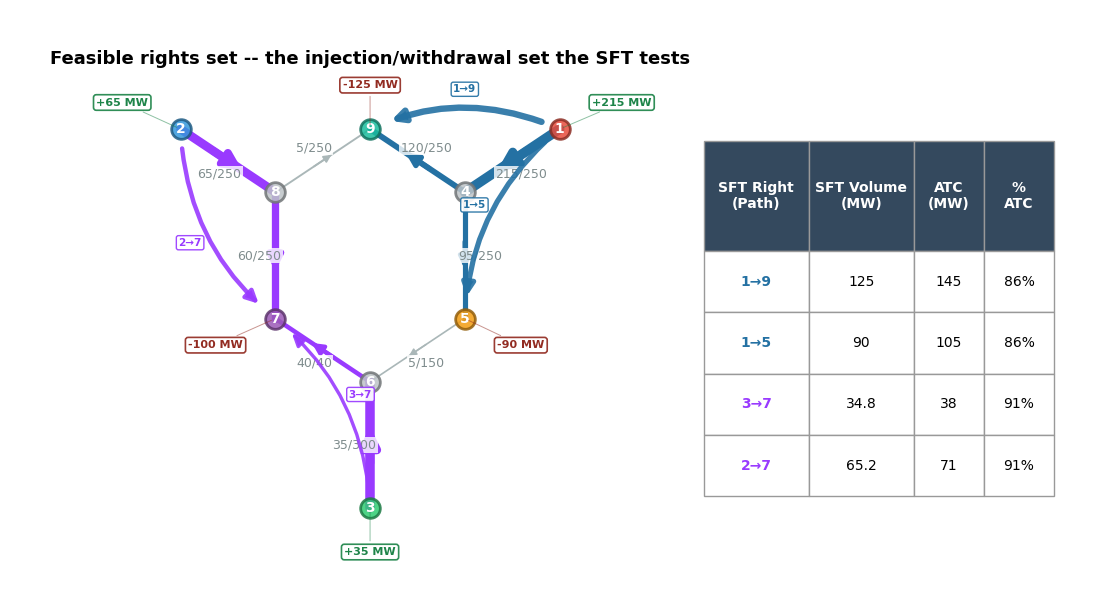

In [7]:
# Feasibility view: rights as arcs, each node's NET injection (+)/withdrawal (-) -- the set the
# SFT tests -- with a PROPORTIONAL ATC: each right gets a share of its BA's binding corridor in
# proportion to its loading, so a shared corridor (BA-2's 1-4, BA-1's line_4) is apportioned, not
# double-counted.  The resulting %ATC is the corridor's utilisation.
rnet = {}
for r in RIGHTS:
    rnet[r['source']] = rnet.get(r['source'], 0.0) + r['mw']
    rnet[r['sink']]   = rnet.get(r['sink'],   0.0) - r['mw']
_ba = {}
for r in RIGHTS: _ba.setdefault(r['tier'], []).append(r)
share = {}
for ba, rs in _ba.items():
    best = None                                           # the BA line its portfolio loads tightest
    for l in atc.ba_monitored_lines(ptC, fp, ba):
        i = ptC.line_idx[l]
        load = sum(rr['mw'] * atc.path_shift_factors(ptC, rr['source'], rr['sink'])[i] for rr in rs)
        frac = abs(load) / float(ptC.s_nom[i])
        if best is None or frac > best[0]: best = (frac, float(ptC.s_nom[i]), abs(load))
    _, cap, sumL = best
    for r in rs:
        share[(r['source'], r['sink'])] = cap * r['mw'] / sumL    # proportional share (path-MW)
atc_prop = [share[(r['source'], r['sink'])] for r in RIGHTS]
figF = figs.rights_figure(build_network({'line_4': 40.0}), ptC, RIGHTS, fp=fp, show_atc=True,
                          line_colors=ba_line_colors(fp), tier_colors=fp.colors, bus_net_mw=rnet,
                          atc_values=atc_prop,
                          col_labels=['SFT Right\n(Path)', 'SFT Volume\n(MW)', 'ATC\n(MW)', '%\nATC'],
                          title='Feasible rights set -- the injection/withdrawal set the SFT tests')
_export(figF, 'fig_rights.png')          # 600-DPI PNG for the lab note
plt.show()

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


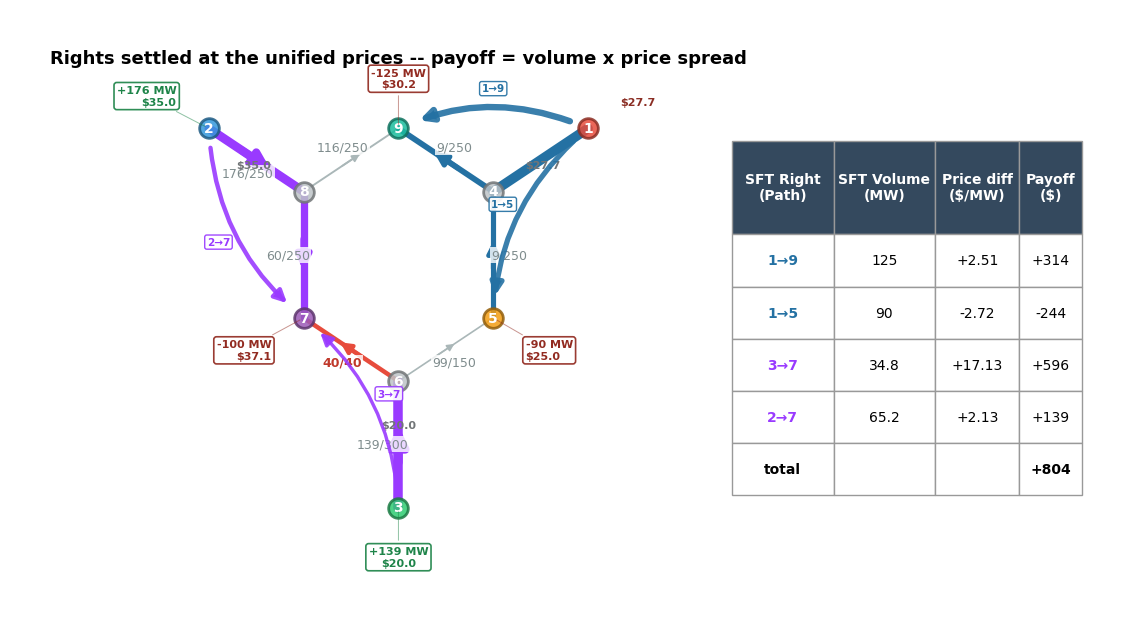

In [8]:
# Settlement view: the same rights over the UNIFIED clearing -- each bus's NET injection (+/-) and
# its LMP, binding line red -- with each right's payoff (volume x price spread).
dnet = {b: resU.gen_by_bus.get(b, 0.0) - wm.DEFAULT_LOADS.get(b, 0.0) for b in ptC.buses}
figS = figs.rights_payoff_figure(build_network({'line_4': 40.0}), ptC, RIGHTS, resU, fp=fp,
                                 line_colors=ba_line_colors(fp), tier_colors=fp.colors, bus_net_mw=dnet,
                                 title='Rights settled at the unified prices -- payoff = volume x price spread')
_export(figS, 'fig_rights_payoff.png')   # 600-DPI PNG for the lab note
plt.show()

In [ ]:
# Combined view: the two network diagrams side by side (feasibility | settlement) as one
# exported image, and the two tables above merged into a single settlement ledger.
from seams_engine import susceptance_widths

netC = build_network({'line_4': 40.0})
lw   = susceptance_widths(ptC)
base = ba_line_colors(fp)                     # per-BA line colours (ties grey)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16.0, 6.6), gridspec_kw=dict(wspace=0.05))

# left -- FEASIBILITY: rights as arcs over each node's net injection/withdrawal; any line the
# netted set overloads (the SFT failing) turns red.
aw    = [atc.Award(r['source'], r['sink'], r['mw']) for r in RIGHTS]
overl = set(atc.overloaded_lines(ptC, aw, 'all'))
lcolF = {l: ('#C0392B' if l in overl else base.get(l, '#CBD0D3')) for l in ptC.lines}
plot_network_topology(netC, bus_colors=BUS_COLORS, bus_coords=COORDS, bus_net_mw=rnet,
                      lmp_only=True, line_flows=atc.flow_dict(ptC, aw), line_colors=lcolF,
                      line_widths=lw, flow_labels=True, constrained_lines=overl, ax=axL,
                      title='Feasible rights set')
figs.draw_rights_arcs(axL, RIGHTS, COORDS, tier_colors=fp.colors, label_mw=False)

# right -- SETTLEMENT: the same rights over the unified clearing (nodal LMPs, dispatch flows),
# the binding line red; each right pays its price spread.
binding = {l for l in ptC.lines if abs(resU.line_dual.get(l, 0.0)) > 1e-3}
lcolS   = {l: ('#C0392B' if l in binding else base.get(l, '#CBD0D3')) for l in ptC.lines}
plot_network_topology(netC, bus_colors=BUS_COLORS, bus_coords=COORDS, bus_lmps=resU.lmp,
                      bus_net_mw=dnet, lmp_only=True,
                      line_flows={l: float(resU.flow_own[l]) for l in ptC.lines},
                      line_colors=lcolS, line_widths=lw, constrained_lines=binding,
                      flow_labels=True, ax=axR,
                      title='Rights settled at the unified prices')
figs.draw_rights_arcs(axR, RIGHTS, COORDS, tier_colors=fp.colors, label_mw=False)

_out = os.path.join('notes', 'status_quo_merchandising', 'figures')
_out = _out if os.path.isdir(_out) else '.'
fig.savefig(os.path.join(_out, 'fig_rights_combined.png'), dpi=600, bbox_inches='tight')
plt.show()

# One ledger from both tables: ATC (feasibility view) + volume, price separation, payoff (settlement).
_atc = dict(zip([(r['source'], r['sink']) for r in RIGHTS], atc_prop))
rows = []
for r in RIGHTS:
    s, k, q = r['source'], r['sink'], float(r['mw'])
    dp = resU.lmp[k] - resU.lmp[s]                          # locational price separation ($/MW)
    rows.append({'Path': f'{s}→{k}', 'ATC (MW)': round(_atc[(s, k)], 1),
                 'SFT Volume (MW)': q, 'Price Separation ($/MW)': round(dp, 2),
                 'Payoff ($)': round(q * dp)})
ledger = pd.DataFrame(rows, columns=['Path', 'ATC (MW)', 'SFT Volume (MW)',
                                     'Price Separation ($/MW)', 'Payoff ($)'])
tot_pay = round(sum((resU.lmp[r['sink']] - resU.lmp[r['source']]) * float(r['mw']) for r in RIGHTS))
ledger.loc[len(ledger)] = ['total', '', ledger['SFT Volume (MW)'].sum(), '', tot_pay]  # total = R

csv_path = os.path.join(_out, 'rights_settlement_table.csv')
ledger.to_csv(csv_path, index=False, encoding='utf-8-sig')   # BOM -> arrows render in Excel
print(f'combined image -> {os.path.join(_out, "fig_rights_combined.png")}')
print(f'settlement ledger (total payoff = R = ${tot_pay:,.0f}) -> {csv_path}')
ledger

**Read it.** Two things the example pins down:

- **Revenue adequacy is the SFT.** The four payoffs total exactly the \$804 the constraint
  collects, because the rights' injection/withdrawal set is simultaneously feasible. Feasibility
  *is* the guarantee -- oversubscribe the set and the rights would be underfunded (the point §6
  generalises).
- **Financial, not firm.** The set fits only on the **netted** test (`line_4` nets to 40 MW): it
  leans on BA-2's relief-side right ($1\to5$) counterflowing the corridor. Its **firm**
  same-direction loading is 52 MW, so it would not clear a no-counterflow rating. The merchandising
  surplus nets positive and negative separations, so reproducing it *requires* netting -- "leave it
  in the BA" corresponds to financial congestion-revenue rights, not firm OATT capacity.

So a feasible set of financial rights reconstructs the very merchandising surplus a balancing
authority would keep: settling the *rights* (sized by a common SFT) and leaving the *surplus* with
the area are two routes to the same dollars, and the choice between them is the allocation question.

## 3. Portfolio planning: each generator builds its book of rights

Before the desk posts ATC, the customers decide what to *ask* for. A
generator-arbitrager values a right $s 	o k$ by the **spread** it could capture
between its own bus and a load center, $p_k - c_s$, and books rights to the centers
where that spread is positive -- ranked by the **revenue opportunity** (the spread
times the energy it could move), up to each path's ATC.

On this network only the cheapest unit is in the money. Bus 3 (\$20) reaches every
load center profitably; bus 2 (\$35) merely breaks even and bus 1 (\$50) is
under water, so **only bus 3 builds a book** -- and it wants to serve *all* the load.
That book is exactly the set of requests the desk rates in the next sections.

In [ ]:
# Each generator values its reach by the spread p_k - c_g it could capture, and books
# rights to the profitable load centers (ranked by revenue opportunity), up to ATC.
lcs = bl.calibrate_load_centers(pt)
suppliers = [bl.Supplier(g, s['bus'], s['cost'], s['p_nom'])
             for g, s in wm.DEFAULT_GEN_FLEET.items()]
opp = pd.DataFrame({
    f"center {k}  (p=${lcs[k].price(lcs[k].d_nom):.0f})":
        {s.gid: round(lcs[k].price(lcs[k].d_nom) - s.cost, 1) for s in suppliers}
    for k in lcs})
print('Margin opportunity  p_k - c_g  ($/MWh): positive => a right worth holding')
display(opp)

books = bl.plan_all(pt, suppliers, lcs)
rows = [{'arbitrager': g, 'right': f'{r.source}->{r.sink}',
         'planned (MW)': round(r.planned_mw, 1),
         'ATC cap (MW)': round(r.cap_mw, 1), 'binds': r.binding_line}
        for g, pf in books.items() for r in pf.rights]
print('\nBooks built (only the cheap bus-3 unit has positive spreads everywhere):')
display(pd.DataFrame(rows).set_index('arbitrager'))

# The bus-3 book is the request set the ATC desk rates next.
bus3 = next(s for s in suppliers if s.bus == '3')
requests = [(r.source, r.sink, r.planned_mw) for r in books[bus3.gid].rights]
print('\nbus-3 requests ->', [(s, k, round(m)) for s, k, m in requests])

Margin opportunity  p_k - c_g  ($/MWh): positive => a right worth holding

,center 5 (p=$35),center 7 (p=$35),center 9 (p=$35)
gen_slack_0,-15.0,-15.0,-15.0
gen_0,0.0,0.0,0.0
gen_1,15.0,15.0,15.0



Books built (only the cheap bus-3 unit has positive spreads everywhere):

,right,planned (MW),ATC cap (MW),binds
arbitrager,,,,
gen_1,3->9,125.0,294.3,line_4
gen_1,3->7,100.0,176.1,line_4
gen_1,3->5,90.0,199.9,line_2



bus-3 requests ->

[('3', '9', 125), ('3', '7', 100), ('3', '5', 90)]

## 4. One footprint: post ATC, then test simultaneous feasibility

A single operator runs the whole 9-bus network and posts ATC on the wheels that
deliver cheap bus-3 (and bus-2) energy to the three loads. Read each posted ATC as
the provider computes it: **as if that path had the network to itself.**

In [ ]:
# The operator posts ATC on each cheap-source wheel, each rated on its own
# (TRM = CBM = ETC = 0, so ATC = TTC).
posted = []
for s, k in [('3', '5'), ('3', '7'), ('3', '9'), ('2', '5'), ('2', '7'), ('2', '9')]:
    mw, binding = atc.ttc(pt, s, k)
    posted.append({'wheel': f'{s}->{k}', 'POR (source)': s, 'POD (sink)': k,
                   'posted ATC (MW)': round(atc.atc(mw), 1), 'binds': binding})
pd.DataFrame(posted).set_index('wheel')

,POR (source),POD (sink),posted ATC (MW),binds
wheel,,,,
3->5,3,5,199.9,line_2
3->7,3,7,176.1,line_4
3->9,3,9,294.3,line_4
2->5,2,5,250.0,line_6
2->7,2,7,250.0,line_6
2->9,2,9,250.0,line_6


Three customers each take service at -- or just under -- the posted ATC, all
sourced at the cheap bus-3 generator: 125 MW to bus 9, 100 MW to bus 7, 90 MW to
bus 5. Every reservation is individually within its posted ATC, so a contract-path
desk grants all three. Now test the *set* against eq. (3).

In [ ]:
# Three customers each take service at/under the posted ATC, all from cheap bus 3:
naive = [atc.Award(*r) for r in requests]   # the planned bus-3 book from Section 3
feasible, loadings = atc.simultaneous_feasibility(pt, naive)
print('Each reservation is within its posted ATC, so all three are granted.')
print('Simultaneous-feasibility test (eq. 3) feasible?', feasible)
loadings

Each reservation is within its posted ATC, so all three are granted.

Simultaneous-feasibility test (eq. 3) feasible?

False

,from,to,flow,limit,loading_%,overload
line,,,,,,
line_0,1,4,-0.0,250.0,0.0,False
line_1,4,5,-53.6,250.0,21.0,False
line_2,5,6,-143.6,150.0,96.0,False
line_3,3,6,315.0,300.0,105.0,True
line_4,6,7,171.4,150.0,114.0,True
line_5,7,8,71.4,250.0,29.0,False
line_6,8,2,0.0,250.0,0.0,False
line_7,8,9,71.4,250.0,29.0,False
line_8,9,4,-53.6,250.0,21.0,False


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


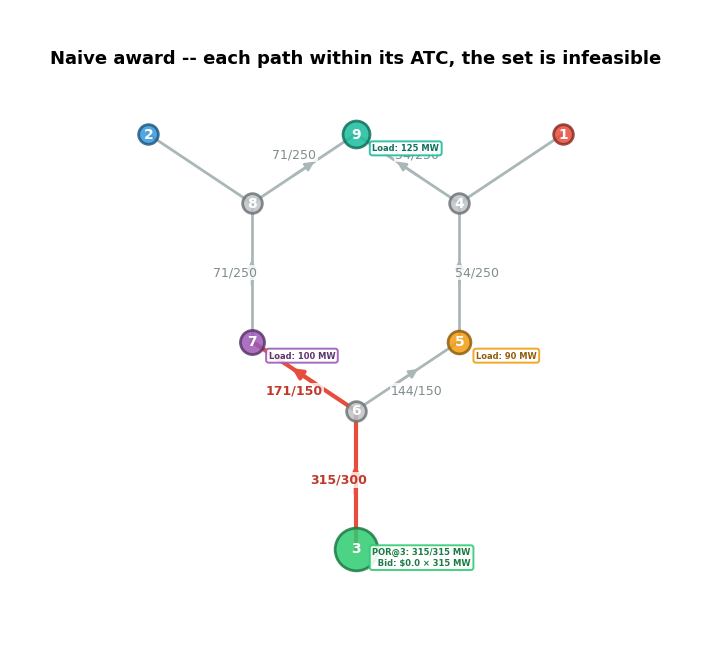

In [ ]:
award_figure(naive, 'Naive award -- each path within its ATC, the set is infeasible')

The set fails: $\texttt{line\_3}$ (3-6) at 105% and $\texttt{line\_4}$
(6-7) at 114%. Two posted wheels share the 3-6 corridor, each was rated alone, so
selling both overloads it -- and 315 MW is drawn at bus 3 where only 170 MW of
generation sits. Posting ATC path-by-path **oversubscribed** both the corridor and
the source.

The fix inside one footprint is the SFT itself, run as reservations book: rate each
new request against the capability **already committed** (its $\mathrm{ETC}$), not
against an empty network. Process the same three requests in queue order.

In [ ]:
# The fix in one footprint: rate each new request against capability already
# committed (its ETC), in queue order -- so the booked set stays feasible (eq. 3).
booked = atc.book_sequentially(pt, requests)   # rate the same planned book in queue order
for a in booked:
    print(f'  {a.source}->{a.sink}: requested -> granted {a.mw:5.1f} MW')
feasible_b, loadings_b = atc.simultaneous_feasibility(pt, booked)
print('SFT feasible?', feasible_b)
loadings_b

  3->9: requested -> granted 125.0 MW

  3->7: requested -> granted 100.0 MW

  3->5: requested -> granted   4.4 MW

SFT feasible?

True

,from,to,flow,limit,loading_%,overload
line,,,,,,
line_0,1,4,-0.0,250.0,0.0,False
line_1,4,5,-75.0,250.0,30.0,False
line_2,5,6,-79.4,150.0,53.0,False
line_3,3,6,229.4,300.0,76.0,False
line_4,6,7,150.0,150.0,100.0,False
line_5,7,8,50.0,250.0,20.0,False
line_6,8,2,0.0,250.0,0.0,False
line_7,8,9,50.0,250.0,20.0,False
line_8,9,4,-75.0,250.0,30.0,False


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


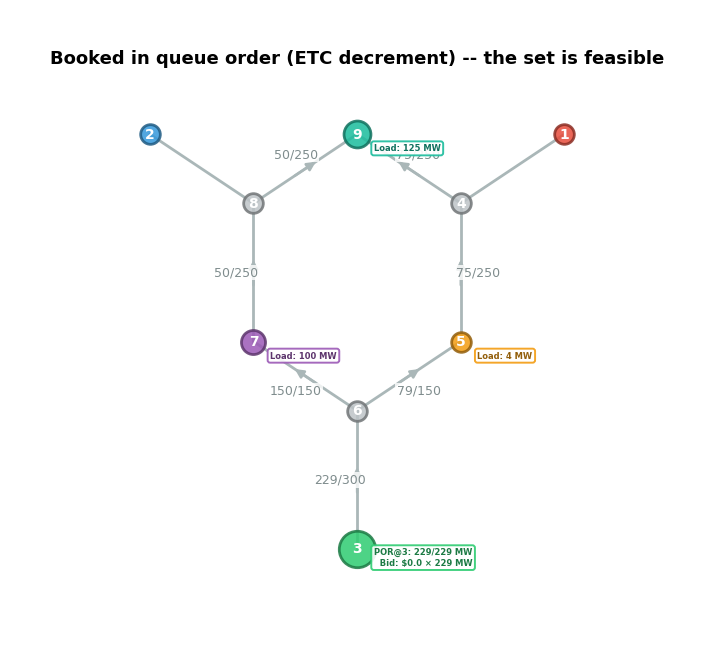

In [ ]:
award_figure(booked, 'Booked in queue order (ETC decrement) -- the set is feasible')

Now the set is feasible. The third request is curtailed because the first two
already committed the 3-6 corridor. This is the **simultaneous-feasibility
condition**: a set of transmission rights is awardable only if the flows it implies
can coexist on the network. It is also what makes the rights revenue-adequate -- the
congestion collected at delivery covers what the rights pay out only when the awarded
set is simultaneously feasible. One operator, seeing the whole network, can hold the
line. The trouble starts when no one does.

## 5. Two balancing authorities, each selling all its ATC

Split the network into two balancing authorities, each running its own ATC desk.
BA-1 = buses {2, 3, 6, 7, 8} (the cheap fleet at buses 2 and 3); BA-2 = buses
{1, 4, 5, 9}. The two cross-boundary lines -- $\texttt{line\_2}$ (5-6) and
$\texttt{line\_7}$ (8-9) -- are ties; each BA rates the ties, but **each rates only
its own internal lines.** Neither sees the other's internal facilities.

tie lines (both BAs rate these):

['line_2', 'line_7']

BA-1 monitors:

['line_2', 'line_3', 'line_4', 'line_5', 'line_6', 'line_7']

BA-2 monitors:

['line_0', 'line_1', 'line_2', 'line_7', 'line_8']

  (no line_4 -- BA-1's)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


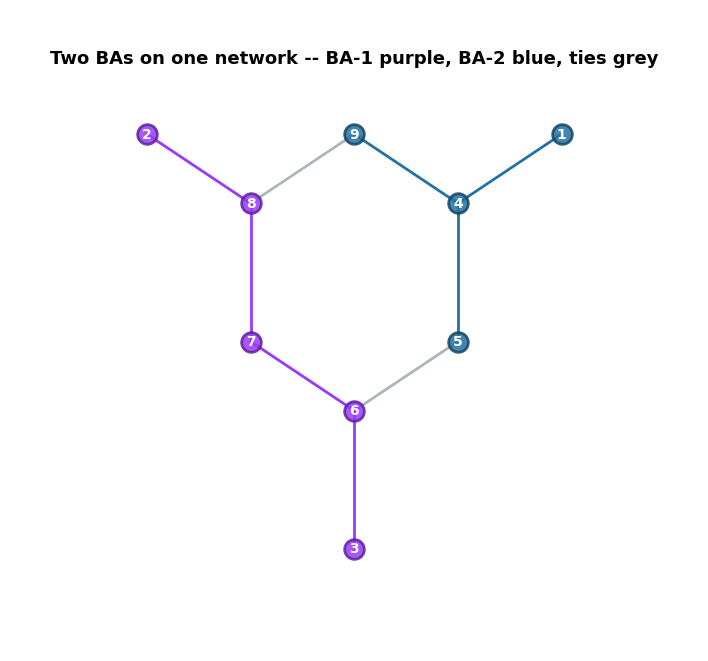

In [ ]:
# Two balancing authorities, each running its own ATC desk.
BA_DEFS = {'BA-1': ['2', '8', '7', '6', '3'], 'BA-2': ['1', '9', '4', '5']}
fp = fpmod.make(pt, BA_DEFS, {'BA-1': '#993AFF', 'BA-2': '#2471A3'}, tie_label='tie')
print('tie lines (both BAs rate these):', fp.ties)
print('BA-1 monitors:', atc.ba_monitored_lines(pt, fp, 'BA-1'))
print('BA-2 monitors:', atc.ba_monitored_lines(pt, fp, 'BA-2'), '  (no line_4 -- BA-1\'s)')

net = build_network()
ba_bus_colors = {b: fp.colors[fp.fp_of(b)] for b in pt.buses if fp.fp_of(b)}
fig, ax = plot_network_topology(
    net, bus_colors=ba_bus_colors, bus_coords=COORDS,
    line_colors=ba_line_colors(fp),
    title='Two BAs on one network -- BA-1 purple, BA-2 blue, ties grey')
plt.show()

Each BA picks a wheel wholly inside its own footprint and posts ATC on it through
only its own monitored lines. Both desks check their own books -- and both pass.

In [ ]:
# Each BA posts ATC on its own wheel, rating it through ONLY its own lines.
a1, b1 = atc.ba_atc(pt, fp, 'BA-1', '3', '7')   # cheap fleet -> its bus-7 load
a2, b2 = atc.ba_atc(pt, fp, 'BA-2', '1', '9')   # its unit -> its bus-9 load
print(f'BA-1 posts ATC for 3->7: {a1:.0f} MW  (binds {b1}, its own line)')
print(f'BA-2 posts ATC for 1->9: {a2:.0f} MW  (binds {b2}, its own line)')

mon1 = atc.ba_monitored_lines(pt, fp, 'BA-1')
mon2 = atc.ba_monitored_lines(pt, fp, 'BA-2')
ok1, _ = atc.simultaneous_feasibility(pt, [atc.Award('3', '7', a1)], monitored=mon1)
ok2, _ = atc.simultaneous_feasibility(pt, [atc.Award('1', '9', a2)], monitored=mon2)
print(f'BA-1 own-footprint SFT: {ok1}   |   BA-2 own-footprint SFT: {ok2}')

BA-1 posts ATC for 3->7: 176 MW  (binds line_4, its own line)

BA-2 posts ATC for 1->9: 250 MW  (binds line_0, its own line)

BA-1 own-footprint SFT: True   |   BA-2 own-footprint SFT: True

In [ ]:
# Each BA sells its full ATC. Now test the combined set on the WHOLE network.
combined = [atc.Award('3', '7', a1), atc.Award('1', '9', a2)]
feasible_c, loadings_c = atc.simultaneous_feasibility(pt, combined)
print('Network-wide SFT feasible?', feasible_c)
loadings_c

Network-wide SFT feasible?

False

,from,to,flow,limit,loading_%,overload
line,,,,,,
line_0,1,4,250.0,250.0,100.0,False
line_1,4,5,5.1,250.0,2.0,False
line_2,5,6,5.1,150.0,3.0,False
line_3,3,6,176.1,300.0,59.0,False
line_4,6,7,181.2,150.0,121.0,True
line_5,7,8,5.1,250.0,2.0,False
line_6,8,2,0.0,250.0,0.0,False
line_7,8,9,5.1,250.0,2.0,False
line_8,9,4,-244.9,250.0,98.0,False


In [ ]:
# Who loads line_4? Decompose the 6-7 flow by transaction.
i4 = pt.line_idx['line_4']
rows = []
for label, a in [('BA-1 wheel 3->7', combined[0]), ('BA-2 wheel 1->9', combined[1])]:
    f4 = a.mw * atc.path_shift_factors(pt, a.source, a.sink)[i4]
    rows.append({'transaction': label, 'awarded MW': round(a.mw, 0),
                 'monitors line_4?': 'yes (its line)' if a is combined[0] else 'NO',
                 'loads line_4 (MW)': round(float(f4), 1)})
dec = pd.DataFrame(rows).set_index('transaction')
print('line_4 rating = 150 MW; combined loading =',
      round(float(dec['loads line_4 (MW)'].sum()), 1), 'MW')
dec

line_4 rating = 150 MW; combined loading =

181.2

MW

,awarded MW,monitors line_4?,loads line_4 (MW)
transaction,,,
BA-1 wheel 3->7,176.0,yes (its line),150.0
BA-2 wheel 1->9,250.0,NO,31.2


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


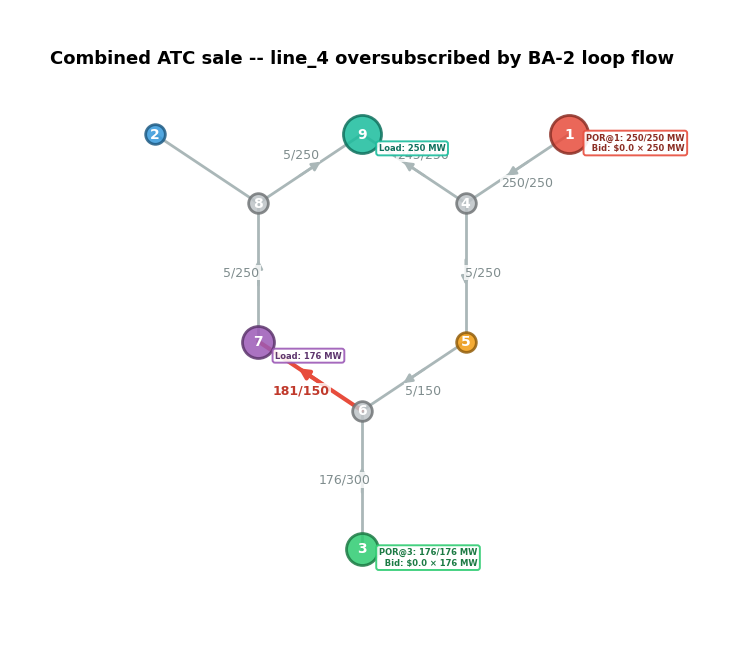

In [ ]:
award_figure(combined, 'Combined ATC sale -- line_4 oversubscribed by BA-2 loop flow')

Each BA's own books are clean, yet the network is oversubscribed:
$\texttt{line\_4}$ (6-7), internal to BA-1, carries 181 MW against a 150 MW rating.
BA-1 had already committed $\texttt{line\_4}$ to its own 176 MW wheel; BA-2's
wholly-internal 1->9 wheel adds about 31 MW of **loop flow** onto it. BA-2 never
monitored $\texttt{line\_4}$ -- it is BA-1's line -- and BA-1 never saw BA-2's
transaction. This is the loop-flow externality at the heart of the Western seams: a
neighbor's schedule quietly consumes your transfer capability, and contract-path ATC
has no way to net it.

In [ ]:
# The coordinated fix: respect the binding flowgate across the WHOLE network and
# share it. Scale both posted wheels by the single factor that brings the worst
# line down to its rating -- a pro-rata share of the simultaneously feasible set.
posted = {'3': a1, '1': a2}
factor = 1.0 / (atc.line_loadings(pt, combined)['loading_%'].max() / 100.0)
coord = [atc.Award(a.source, a.sink, a.mw * factor) for a in combined]
print(f'shared-feasibility factor = {factor:.3f}')
for a in coord:
    print(f'  {a.source}->{a.sink}: posted {posted[a.source]:.0f} -> feasible {a.mw:5.1f} MW')
feasible_co, loadings_co = atc.simultaneous_feasibility(pt, coord)
print('SFT feasible?', feasible_co)
loadings_co

shared-feasibility factor = 0.826

  3->7: posted 176 -> feasible 145.5 MW

  1->9: posted 250 -> feasible 206.6 MW

SFT feasible?

True

,from,to,flow,limit,loading_%,overload
line,,,,,,
line_0,1,4,206.6,250.0,83.0,False
line_1,4,5,4.3,250.0,2.0,False
line_2,5,6,4.3,150.0,3.0,False
line_3,3,6,145.5,300.0,49.0,False
line_4,6,7,149.8,150.0,100.0,False
line_5,7,8,4.3,250.0,2.0,False
line_6,8,2,0.0,250.0,0.0,False
line_7,8,9,4.3,250.0,2.0,False
line_8,9,4,-202.4,250.0,81.0,False


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


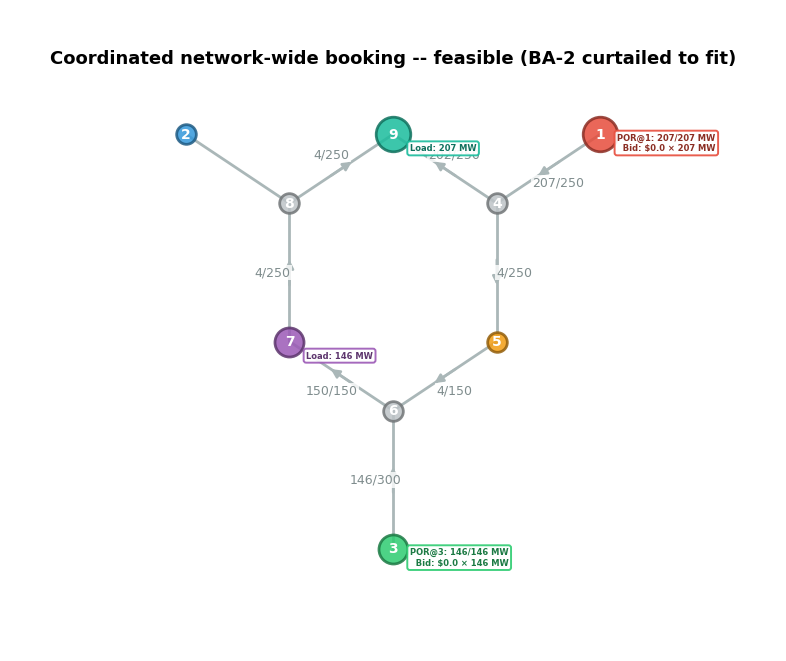

In [ ]:
award_figure(coord, 'Coordinated network-wide booking -- feasible (BA-2 curtailed to fit)')

Coordination shares the binding flowgate instead of letting two desks each claim it.
Scaling both wheels by the single factor that brings $\texttt{line\_4}$ down to its
150 MW rating gives a simultaneously feasible set -- BA-1 about 146 MW, BA-2 about
207 MW. The total firm transfer the network actually supports is well below the sum
the two desks posted; the gap is the capability they jointly oversold. (A strict
reservation queue would instead curtail by priority, zeroing the junior wheel -- same
lesson, a different sharing rule. The point is that *some* network-wide test has to
net the loop flow; per-footprint ATC never does.)

### The reserved-rights portfolio: each generator to its two nearest loads

Close the book into its natural symmetric pattern -- **each generator holds firm rights to its
two nearest loads**, and each load is reachable from two generators (a hexagon of three
generators and three loads):

- **Gen 3** ($20, cheapest) $\to$ loads **7** and **5**: $3\to7$ (internal to BA-1) and $3\to5$
  (**cross-seam**, riding the 5-6 tie into BA-2).
- **Gen 2** ($35) $\to$ loads **7** and **9**: $2\to7$ (internal to BA-1) and $2\to9$
  (**cross-seam**, riding the 8-9 tie into BA-2).
- **Gen 1** ($50, dearest) $\to$ loads **9** and **5**: $1\to9$ and $1\to5$, **both inside BA-2**,
  both leaving bus 1 on the **1-4 corridor** (`line_0`).

Two of the three generators **straddle the seam** -- gen 2 and gen 3 each wheel one delivery
across the neighbour's network (the bilateral, two-network case). The outlier is **gen 1**, whose
whole book sits inside BA-2; because it is the dear unit it is the one most likely to sit idle in
the dispatch, leaving firm transmission a merchant could repurpose to move cheap power to a
high-priced load -- the arbitrage the bilateral-trading material picks up later.

**Two properties of *firm* rights matter here.** First, a generator may reserve **more rights than
its nameplate** -- gen 3 books 190 MW against a 170 MW unit -- to keep access to every profitable
load it might serve; carrying firm rights it cannot all deliver simultaneously is an ordinary
inefficiency of a bilateral market, the price of optionality. Second, firm rights are rated
**without crediting counterflow**: a right must be deliverable even if the rights that happen to
counter-flow it are not scheduled, so the feasibility test sums each line's *same-direction*
commitments rather than the netted (superposed) flow. The book passes that conservative test --
every line's firm loading sits within its rating -- so it is a valid *firm* ATC posting, not merely
an efficient-dispatch one.

Lines are coloured by managing BA (6-5 = `line_2` $\to$ BA-1, 8-9 = `line_7` $\to$ BA-2) and drawn
with width $\propto$ susceptance $b_m = 1/x_m$. The print-out gives each generator's book, the firm
(no-counterflow) loading of the binding lines, and each wheel's contribution to BA-1's internal
flowgate $6\to7$ (`line_4`).

generator books (firm rights to the two nearest loads):

  gen 3 (BA-1, nameplate 170 MW): reserves 190 MW  (> nameplate: market-access optionality);  cross-seam wheels: ['3->5']

  gen 2 (BA-1, nameplate 300 MW): reserves 225 MW;  cross-seam wheels: ['2->9']

  gen 1 (BA-2, nameplate 250 MW): reserves 215 MW;  cross-seam wheels: none


firm-rights feasible (no counterflow credit)? True   |   netted SFT (credits counterflow): True

...

   2->7 100 MW (internal  ):   +10.6 MW on line_4   (loads it)

   2->9 125 MW (cross-seam):   -29.6 MW on line_4   (relieves it)

   1->9 125 MW (internal  ):   +15.6 MW on line_4   (loads it)

   1->5  90 MW (internal  ):   -12.2 MW on line_4   (relieves it)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


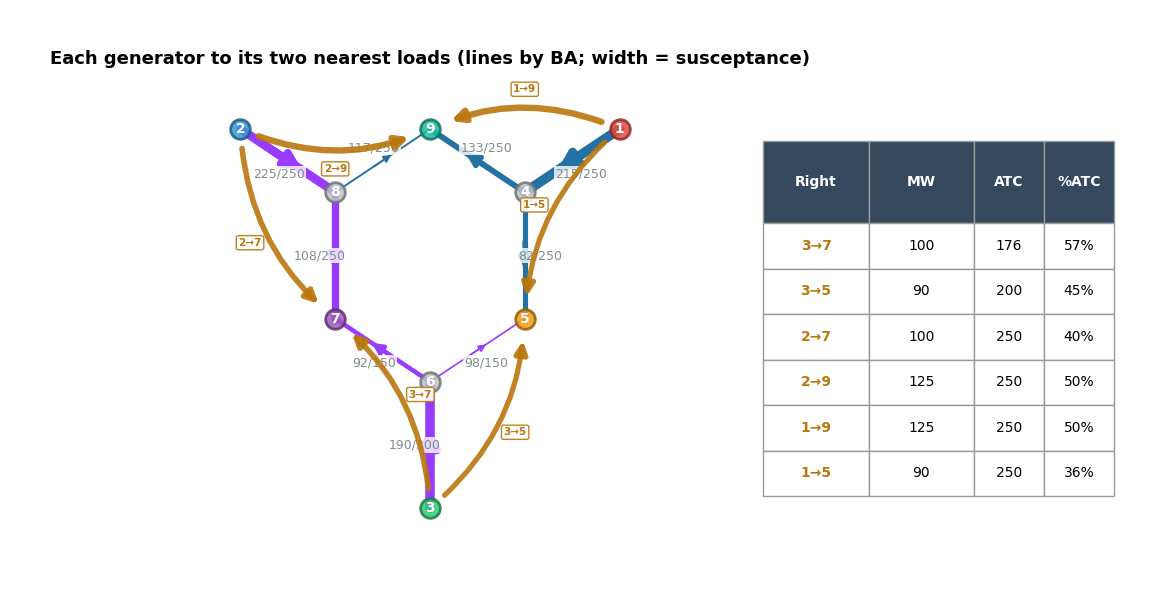

In [ ]:
import wscc9_figures as figs   # the layered rights view (arcs + OATT/ATC table)
# -- EDIT -- each generator's firm rights to its two NEAREST loads (source, sink, MW) --------
HEX = [('3', '7', 100), ('3', '5', 90),     # gen 3 ($20): loads 7 and 5  (3->5 cross-seam)
       ('2', '7', 100), ('2', '9', 125),    # gen 2 ($35): loads 7 and 9  (2->9 cross-seam)
       ('1', '9', 125), ('1', '5', 90)]     # gen 1 ($50): loads 9 and 5  (both inside BA-2)
# -------------------------------------------------------------------------------------------
book = [{'source': s, 'sink': k, 'mw': q, 'tier': 'intra'} for s, k, q in HEX]
aw = [atc.Award(r['source'], r['sink'], r['mw']) for r in book]

BA = {'BA-1': ['2', '8', '7', '6', '3'], 'BA-2': ['1', '9', '4', '5']}
ba_of = {b: k for k, v in BA.items() for b in v}
CAP = {s['bus']: s['p_nom'] for s in wm.DEFAULT_GEN_FLEET.values()}      # generator nameplate

# Per-generator book: total reserved vs nameplate, and which wheels cross the seam.
print('generator books (firm rights to the two nearest loads):')
for g in ['3', '2', '1']:
    mine = [r for r in book if r['source'] == g]
    tot = sum(r['mw'] for r in mine)
    xs = [f"{r['source']}->{r['sink']}" for r in mine if ba_of[r['sink']] != ba_of[g]]
    opt = '  (> nameplate: market-access optionality)' if tot > CAP[g] + 1e-6 else ''
    print(f"  gen {g} ({ba_of[g]}, nameplate {CAP[g]:.0f} MW): reserves {tot:.0f} MW{opt};"
          f"  cross-seam wheels: {xs or 'none'}")

# FIRM feasibility -- the ATC standard, which does NOT credit counterflow (sums each line's
# same-direction commitments), vs the netted simultaneous_feasibility that does. Both pass here,
# but the firm loadings are higher because they do not lean on the counter-flowing wheels.
firm_ok, firm_df = atc.firm_feasibility(pt, aw)
print(f"\nfirm-rights feasible (no counterflow credit)? {firm_ok}"
      f"   |   netted SFT (credits counterflow): {atc.simultaneous_feasibility(pt, aw)[0]}")
print('firm loading of the most-loaded lines (same-direction MW / rating):')
for l, row in firm_df.sort_values('loading_%', ascending=False).head(4).iterrows():
    print(f"   {l} ({row['from']}-{row['to']}): {row['firm']:.0f}/{row['limit']:.0f} MW"
          f"  ({row['loading_%']:.0f}%;  fwd {row['fwd']:.0f}, rev {row['rev']:.0f})")

print("each wheel's contribution to BA-1's internal flowgate 6->7 (line_4):")
i4 = pt.line_idx['line_4']
for r in book:
    sf = atc.path_shift_factors(pt, r['source'], r['sink'])[i4]
    seam = 'cross-seam' if ba_of[r['sink']] != ba_of[r['source']] else 'internal  '
    print(f"   {r['source']}->{r['sink']} {r['mw']:>3.0f} MW ({seam}):  {r['mw'] * sf:+6.1f} MW on line_4"
          f"   ({'loads' if sf > 0 else 'relieves'} it)")

ba_line_color = {l: fp.colors[ba] for ba, ls in
                 {'BA-1': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],
                  'BA-2': ['line_0', 'line_1', 'line_7', 'line_8']}.items() for l in ls}
figs.rights_figure(build_network(), pt, book, fp=fp, show_atc=True, line_colors=ba_line_color,
                   title='Each generator to its two nearest loads (lines by BA; width = susceptance)')
plt.show()

## 6. Why it matters

The two-BA result is the Western seams problem in miniature. Contract-path ATC
(Rated System Path, MOD-029) rates a transfer largely on the seller's own facilities.
But power flows on **every** parallel path, so a transaction inside one balancing
authority loads its neighbors' lines. When each authority computes ATC on its own
slice and sells all of it, the awards are each locally feasible yet jointly
infeasible -- the combined ATC **oversubscribes** the simultaneously feasible set.

Three takeaways:

- **Feasibility is a property of the set, not the path.** Eq. (3) -- the SFT -- is
  the test; ATC posted path-by-path is only a proxy, and a leaky one across seams.
- **Revenue adequacy rides on the SFT.** If these were financial transmission
  rights, the congestion collected covers the payouts only on a simultaneously
  feasible award set. Oversubscribe it and the rights are underfunded.
- **The fix is flow-based coordination.** A single network-wide feasibility test
  (one operator, a shared flowgate budget, or a joint market) nets the loop flow
  that contract-path ATC cannot. This is the case for flow-based, nodal coordination
  -- and it is why allocating the resulting congestion revenue across authorities
  that still hold OATT obligations is the open design question this Lab works on.

## 7. Sandbox

Change the line ratings, the award set, or the booking rule and re-run. With
`QUEUE_BOOKING = False` you test a raw set against eq. (3); with `True` the awards
book in order and decrement ATC (the in-footprint fix). Tighten a flowgate (e.g.
`{'line_4': 120}`) to force oversubscription sooner.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


granted:

[('3->9', 125.0), ('3->7', 100.0), ('3->5', 90.0)]

SFT feasible?

False

,from,to,flow,limit,loading_%,overload
line,,,,,,
line_0,1,4,-0.0,250.0,0.0,False
line_1,4,5,-53.6,250.0,21.0,False
line_2,5,6,-143.6,150.0,96.0,False
line_3,3,6,315.0,300.0,105.0,True
line_4,6,7,171.4,150.0,114.0,True
line_5,7,8,71.4,250.0,29.0,False
line_6,8,2,0.0,250.0,0.0,False
line_7,8,9,71.4,250.0,29.0,False
line_8,9,4,-53.6,250.0,21.0,False


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


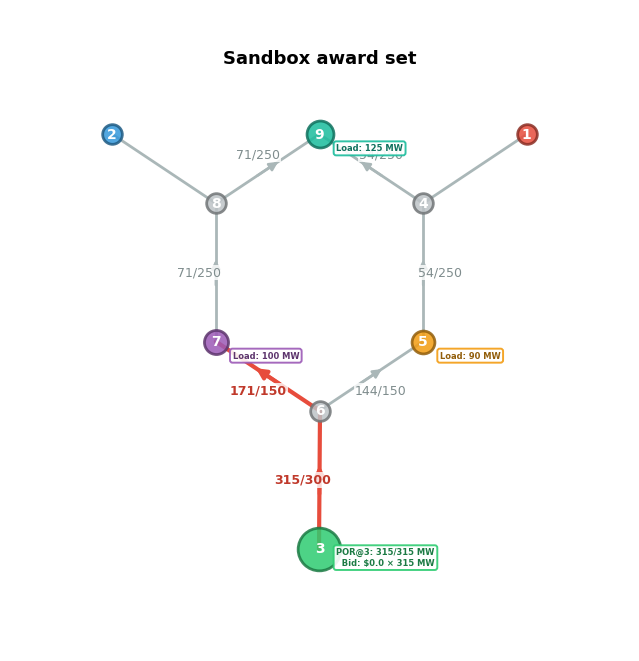

In [ ]:
# ============================ SANDBOX -- EDIT HERE ============================
RATINGS = {}                       # tighten a flowgate, e.g. {'line_4': 120}
AWARDS  = [('3', '9', 125),        # (source bus, sink bus, MW) point-to-point awards
           ('3', '7', 100),
           ('3', '5', 90)]
QUEUE_BOOKING = False              # False: grant as requested (test the raw set)
                                   # True : book in order, decrement ATC (ETC)
# =============================================================================
pt_sb = compute_ptdf(build_network(line_ratings=RATINGS), slack_bus='1')
if QUEUE_BOOKING:
    awards_sb = atc.book_sequentially(pt_sb, AWARDS)
else:
    awards_sb = [atc.Award(*a) for a in AWARDS]

ok_sb, load_sb = atc.simultaneous_feasibility(pt_sb, awards_sb)
print('granted:', [(f'{a.source}->{a.sink}', round(a.mw, 1)) for a in awards_sb])
print('SFT feasible?', ok_sb)
display(load_sb)
award_figure(awards_sb, 'Sandbox award set', ptx=pt_sb,
             net=build_network(line_ratings=RATINGS))